# CIFAR-10 Image Classification: ANN vs CNN

This notebook follows the assignment steps exactly:
1. Load CIFAR-10 (50,000 train / 10,000 test images)
2. Normalize pixel values (0-255 → 0-1)
3. Build a baseline ANN (Dense + Dropout)
4. Build a CNN (Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense)
5. Compile both with Adam optimizer, train 10 epochs, sparse categorical cross-entropy
6. Plot validation accuracy curves for both on a single chart
7. Build an augmented CNN variant (RandomFlip, RandomRotation, RandomZoom)
8. Complete all student tasks: deeper ANN, scaled filters (32→64→128), 20 epochs, EarlyStopping, and actually run the augmented training

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1: Load the CIFAR-10 Dataset

CIFAR-10 comes **built into Keras** — no manual download needed. Calling `tf.keras.datasets.cifar10.load_data()` will automatically download the dataset (~170MB) from Keras's own server the first time you run it, and cache it locally at `~/.keras/datasets/cifar-10-batches-py`.

If you ever want it from elsewhere (e.g. to inspect manually or use outside Keras), the original source is the University of Toronto page: **https://www.cs.toronto.edu/~kriz/cifar.html** (look for the "CIFAR-10 python version" download). It's also mirrored on Kaggle (search "CIFAR-10") and on Hugging Face Datasets (`uoft-cs/cifar10`). But for this notebook, the Keras built-in loader below is all you need.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


### Quick look at sample images

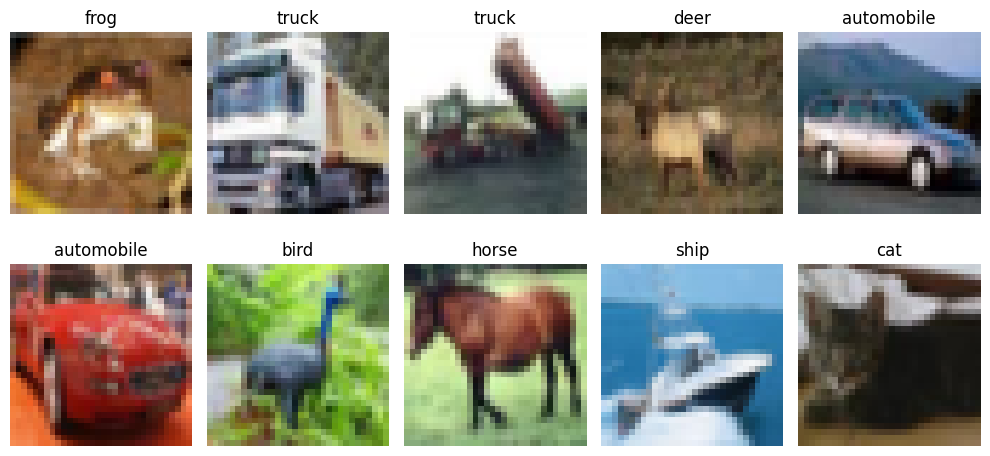

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Normalize Pixel Values (0-255 → 0-1)

Raw pixel values are integers from 0 to 255. Dividing by 255 rescales them to floats between 0 and 1, which stabilizes gradients during training.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flattened versions for the ANN (which needs 1D vectors, not 3D images)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Pixel range after normalization:", x_train_norm.min(), "to", x_train_norm.max())
print("Flattened ANN input shape:", x_train_flat.shape)

Pixel range after normalization: 0.0 to 1.0
Flattened ANN input shape: (50000, 3072)


## Step 3: Baseline ANN Model

A plain ANN treats the image as a flat vector of 3,072 numbers (32×32×3), so it has no notion of spatial structure — it just sees a long list of pixel values. Built with **Dense** and **Dropout** layers.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: CNN Model

Built with **Conv2D**, **BatchNormalization**, **MaxPooling2D**, **Flatten**, and **Dense** classification layers. Convolution preserves spatial relationships between neighboring pixels, which is why CNNs handle images far better than plain ANNs.

In [6]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

## Step 5: Compile and Train Both Models
Both use the **Adam optimizer**, **sparse categorical cross-entropy** loss, and train for **10 epochs**.

In [7]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2689 - loss: 1.9931 - val_accuracy: 0.3088 - val_loss: 1.9004
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3135 - loss: 1.8722 - val_accuracy: 0.3574 - val_loss: 1.7799
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3284 - loss: 1.8333 - val_accuracy: 0.3688 - val_loss: 1.7849
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3443 - loss: 1.7961 - val_accuracy: 0.3750 - val_loss: 1.7545
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3517 - loss: 1.7709 - val_accuracy: 0.3946 - val_loss: 1.7139
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3626 - loss: 1.7534 - val_accuracy: 0.3906 - val_loss: 1.7261
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3657 - loss: 1.7428 - val_accuracy: 0.4004 - val_loss: 1.7006
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3721 - loss: 1.7338 - val_accuracy: 0.

In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4585 - loss: 1.5124 - val_accuracy: 0.5512 - val_loss: 1.2296
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6089 - loss: 1.1205 - val_accuracy: 0.6538 - val_loss: 1.0022
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6694 - loss: 0.9497 - val_accuracy: 0.6446 - val_loss: 1.0408
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7129 - loss: 0.8293 - val_accuracy: 0.6338 - val_loss: 1.1358
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7460 - loss: 0.7350 - val_accuracy: 0.7086 - val_loss: 0.8536
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7715 - loss: 0.6555 - val_accuracy: 0.6306 - val_loss: 1.1048
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7885 - loss: 0.5943 - val_accuracy: 0.7048 - val_loss: 0.9050
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8128 - loss: 0.5364 - val_accuracy: 

## Step 6: Plot Validation Accuracy — Both Models on One Chart

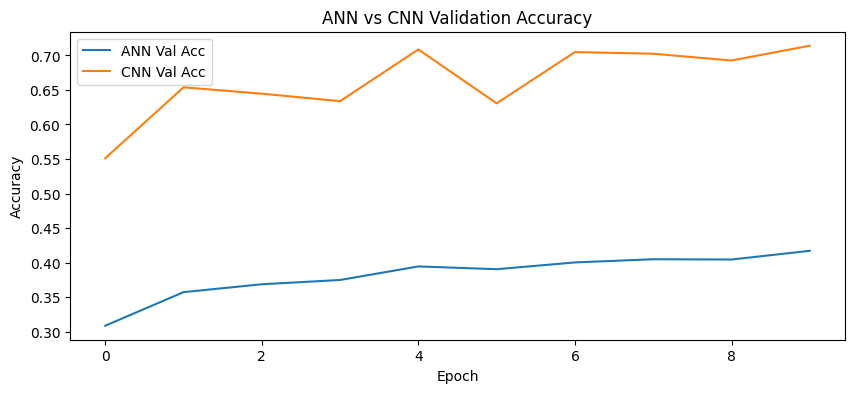

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

## Step 7: Augmented CNN Variant
Adds **RandomFlip**, **RandomRotation**, and **RandomZoom** as a preprocessing layer inside the model so augmentation happens on-the-fly during training only (not on validation/test data).

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 8: Student Tasks — Implemented and Run
- Deeper ANN (more Dense layers)
- CNN filters scaled 32 → 64 → 128 (already used above; here re-trained for 20 epochs with EarlyStopping)
- Training extended to 20 epochs
- EarlyStopping added
- Augmented network actually trained (not just defined)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Deeper ANN: more Dense layers than the baseline
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2543 - loss: 2.0169 - val_accuracy: 0.3260 - val_loss: 1.8637
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3104 - loss: 1.8789 - val_accuracy: 0.3448 - val_loss: 1.7988
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3280 - loss: 1.8382 - val_accuracy: 0.3536 - val_loss: 1.7743
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3378 - loss: 1.8044 - val_accuracy: 0.3660 - val_loss: 1.7648
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3468 - loss: 1.7828 - val_accuracy: 0.3878 - val_loss: 1.7269
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3610 - loss: 1.7547 - val_accuracy: 0.3846 - val_loss: 1.7106
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3634 - loss: 1.7440 - val_accuracy: 0.3890 - val_loss: 1.6956
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3706 - loss: 1.7264 - val_accuracy: 0

In [12]:
# CNN with filters 32 -> 64 -> 128, retrained for 20 epochs with EarlyStopping
scaled_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

scaled_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scaled_cnn_history = scaled_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

scaled_cnn_test_loss, scaled_cnn_test_acc = scaled_cnn_model.evaluate(x_test_norm, y_test)
print("Scaled CNN Test Accuracy:", scaled_cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4809 - loss: 1.5324 - val_accuracy: 0.5616 - val_loss: 1.2038
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6221 - loss: 1.0810 - val_accuracy: 0.4480 - val_loss: 1.7111
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6792 - loss: 0.9224 - val_accuracy: 0.6568 - val_loss: 0.9801
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7185 - loss: 0.8049 - val_accuracy: 0.5990 - val_loss: 1.2793
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7491 - loss: 0.7187 - val_accuracy: 0.6936 - val_loss: 0.9256
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7717 - loss: 0.6430 - val_accuracy: 0.6956 - val_loss: 0.8979
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7960 - loss: 0.5728 - val_accuracy: 0.6826 - val_loss: 0.9629
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8140 - loss: 0.5261 - val_accuracy: 

In [13]:
# Actually run the augmented training (20 epochs + EarlyStopping)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3582 - loss: 1.7557 - val_accuracy: 0.4688 - val_loss: 1.4806
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4542 - loss: 1.5167 - val_accuracy: 0.5346 - val_loss: 1.2866
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4896 - loss: 1.4180 - val_accuracy: 0.5786 - val_loss: 1.1715
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4643 - loss: 1.4833
Augmented CNN Test Accuracy: 0.4643000066280365


## Final Comparison: All Models

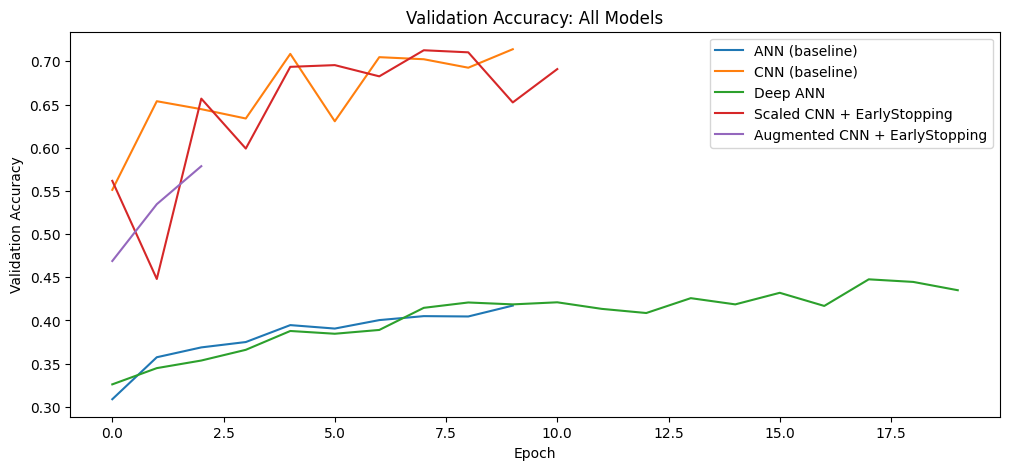

,Model,Test Accuracy
0,Scaled CNN + EarlyStopping,0.7106
1,CNN (baseline),0.7077
2,Augmented CNN + EarlyStopping,0.4643
3,Deep ANN,0.4477
4,ANN (baseline),0.4186


In [14]:
plt.figure(figsize=(12,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline)')
plt.plot(deep_ann_history.history['val_accuracy'], label='Deep ANN')
plt.plot(scaled_cnn_history.history['val_accuracy'], label='Scaled CNN + EarlyStopping')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN + EarlyStopping')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.show()

final_comparison = pd.DataFrame({
    "Model": ["ANN (baseline)", "CNN (baseline)", "Deep ANN", "Scaled CNN + EarlyStopping", "Augmented CNN + EarlyStopping"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, deep_ann_test_acc, scaled_cnn_test_acc, aug_test_acc]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

final_comparison

## Conclusion
- **ANN** treats the image as a flat vector and ignores spatial structure, so it tops out lower no matter how many Dense layers are added.
- **CNN** preserves spatial relationships via convolution + pooling, consistently outperforming ANN.
- **Deeper ANN** gives at best a small improvement over the baseline ANN, and risks overfitting faster — which is why EarlyStopping matters.
- **Longer training + EarlyStopping** lets the CNN reach a better validation point without wasting epochs once it stops improving.
- **Data augmentation** trades a bit of raw training accuracy for better generalization, usually helping test accuracy versus the non-augmented CNN.
- **Overall**: CNN-based architectures are the clear winner for image classification tasks like CIFAR-10.